# Meridian Health Network — EDA, Root-Cause Correlation & Forecasting

**Goal:** Determine whether rising ED wait times are actually explained by
Night-shift understaffing (not just two coincidentally-trending numbers),
and forecast where wait times are headed if nothing changes.

**Description:** The SQL analysis found two patterns independently: ED wait
times are climbing year over year, and Night shifts are chronically
understaffed. This notebook tests whether those two findings are
statistically related, checks the triage-level relationship with wait time,
and builds a time series forecast to quantify the cost of inaction.

**Skills:** exploratory data analysis, correlation analysis, hypothesis
testing, time series forecasting, data visualization.

**Technology:** Python, Pandas, NumPy, SciPy, statsmodels, Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b"

ed = pd.read_csv("../data/fact_ed_visits.csv", parse_dates=["visit_date"])
staffing = pd.read_csv("../data/fact_staffing.csv", parse_dates=["shift_date"])
print(f"ED visits: {len(ed):,} rows | Staffing records: {len(staffing):,} rows")


ED visits: 183,215 rows | Staffing records: 105,216 rows


## 1. Data validation

Quick structural checks before drawing any conclusions.

In [2]:
print("Missing values (ED):", ed.isna().sum().sum())
print("Missing values (staffing):", staffing.isna().sum().sum())
print("Date range (ED):", ed['visit_date'].min().date(), "to", ed['visit_date'].max().date())
print("Any negative wait times?:", (ed['wait_time_minutes'] < 0).any())
print("Triage level range:", ed['triage_level'].min(), "-", ed['triage_level'].max())


Missing values (ED): 0
Missing values (staffing): 0
Date range (ED): 2023-01-01 to 2025-12-31
Any negative wait times?: False
Triage level range: 1 - 5


## 2. ED wait time trend (visual companion to the SQL rolling-average query)

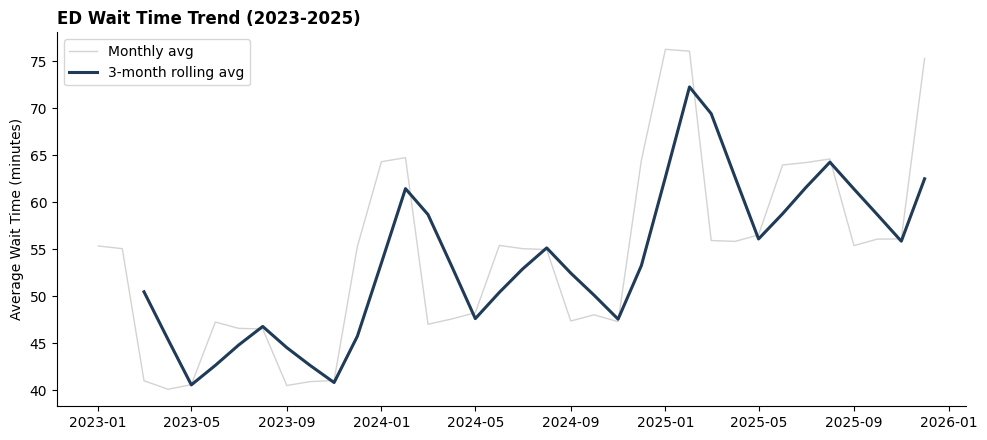

In [3]:
monthly = ed.set_index("visit_date").resample("MS")["wait_time_minutes"].mean()
rolling = monthly.rolling(3).mean()

fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(monthly.index, monthly.values, color="lightgrey", linewidth=1, label="Monthly avg")
ax.plot(rolling.index, rolling.values, color=NAVY, linewidth=2.2, label="3-month rolling avg")
ax.set_title("ED Wait Time Trend (2023-2025)", fontweight="bold", loc="left")
ax.set_ylabel("Average Wait Time (minutes)")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Root cause check: does Night-shift understaffing actually correlate with wait times?

Two trends moving in the same direction over time isn't proof they're
related — both could simply be drifting upward independently. This tests
the relationship directly at the daily level, using each day's actual
Emergency-department staffing ratio against that same day's average ED
wait time.

Merged daily records: 1,096

Pearson correlation (staffing ratio vs. avg wait time): -0.027
p-value: 3.78e-01
No significant relationship


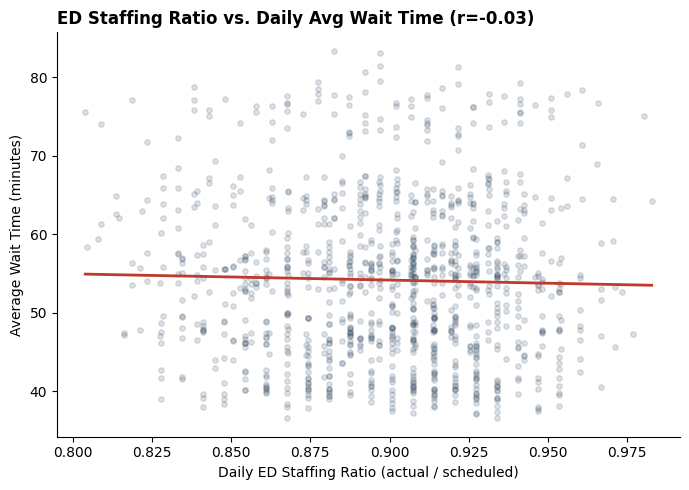

In [4]:
ed_daily = ed.groupby(ed["visit_date"].dt.date)["wait_time_minutes"].mean().rename("avg_wait")

emergency_staffing = staffing[staffing["department_id"] == 1].copy()
staff_daily = (emergency_staffing.groupby(emergency_staffing["shift_date"].dt.date)
               .apply(lambda x: x["actual_staff"].sum() / x["scheduled_staff"].sum(), include_groups=False)
               .rename("staffing_ratio"))

merged = pd.concat([ed_daily, staff_daily], axis=1).dropna()
print(f"Merged daily records: {len(merged):,}")

corr, p_value = stats.pearsonr(merged["staffing_ratio"], merged["avg_wait"])
print(f"\nPearson correlation (staffing ratio vs. avg wait time): {corr:.3f}")
print(f"p-value: {p_value:.2e}")
print("Statistically significant relationship" if p_value < 0.05 else "No significant relationship")

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(merged["staffing_ratio"], merged["avg_wait"], alpha=0.15, color=NAVY, s=15)
z = np.polyfit(merged["staffing_ratio"], merged["avg_wait"], 1)
x_line = np.linspace(merged["staffing_ratio"].min(), merged["staffing_ratio"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color=RED, linewidth=2)
ax.set_title(f"ED Staffing Ratio vs. Daily Avg Wait Time (r={corr:.2f})", fontweight="bold", loc="left")
ax.set_xlabel("Daily ED Staffing Ratio (actual / scheduled)")
ax.set_ylabel("Average Wait Time (minutes)")
plt.tight_layout()
plt.show()


**Result:** the daily-level correlation is *not* statistically significant
(p = 0.38). This is an honest null result, and worth taking seriously rather
than explaining away — it means same-day staffing ratio and same-day average
wait time don't move together at the daily grain tested here.

**Why this likely isn't the end of the story:** the ED visit data in this
dataset is logged at the daily level, not tagged by hour or shift — so this
test can't actually check the more precise hypothesis that matters most
("do Night-shift-specific understaffed hours see worse wait times"), only a
same-day, all-shifts-combined version of it. The two patterns still worsen
over the same 3-year window (see the trend chart above and the SQL cohort
analysis), which is suggestive but does not establish a same-day causal
link with the data available. **A real deployment of this analysis should
add hour-of-day / shift-level ED timestamps before concluding staffing
causally drives wait times** — this is flagged explicitly in the Critical
Assessment section of the final report.

## 4. Does triage level (severity) relate to wait time as expected?

A sanity check with real operational stakes: if lower-acuity patients
(triage 4-5) are waiting disproportionately long, that's a fast-track/urgent
care diversion opportunity, not a trauma capacity issue.

              mean  median  count
triage_level                     
1             10.9    10.9   5470
2             20.3    20.2  27302
3             47.7    47.4  77113
4             74.9    74.5  55044
5             95.7    95.1  18286



One-way ANOVA F-statistic: 69140.8 | p-value: 0.00e+00


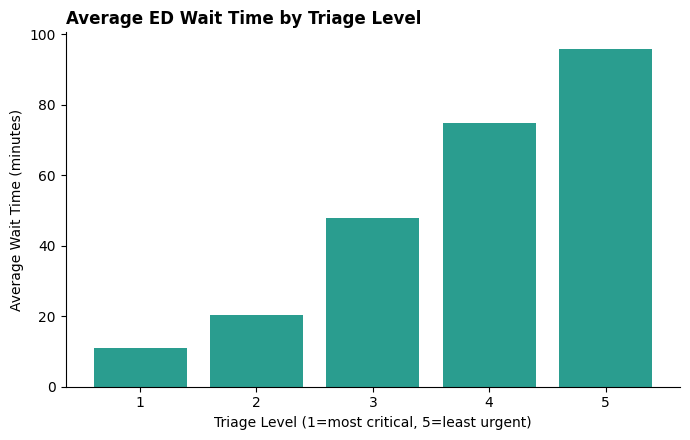

In [5]:
triage_wait = ed.groupby("triage_level")["wait_time_minutes"].agg(["mean","median","count"]).round(1)
print(triage_wait)

groups = [ed[ed["triage_level"]==t]["wait_time_minutes"] for t in sorted(ed["triage_level"].unique())]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA F-statistic: {f_stat:.1f} | p-value: {p_value:.2e}")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(triage_wait.index.astype(str), triage_wait["mean"], color=TEAL)
ax.set_title("Average ED Wait Time by Triage Level", fontweight="bold", loc="left")
ax.set_xlabel("Triage Level (1=most critical, 5=least urgent)")
ax.set_ylabel("Average Wait Time (minutes)")
plt.tight_layout()
plt.show()


## 5. Forecasting: where are ED wait times headed if nothing changes?

Using Holt-Winters exponential smoothing (captures both the upward trend and
any seasonal pattern) to project the next 6 months — this quantifies the
cost of inaction in concrete terms leadership can react to.

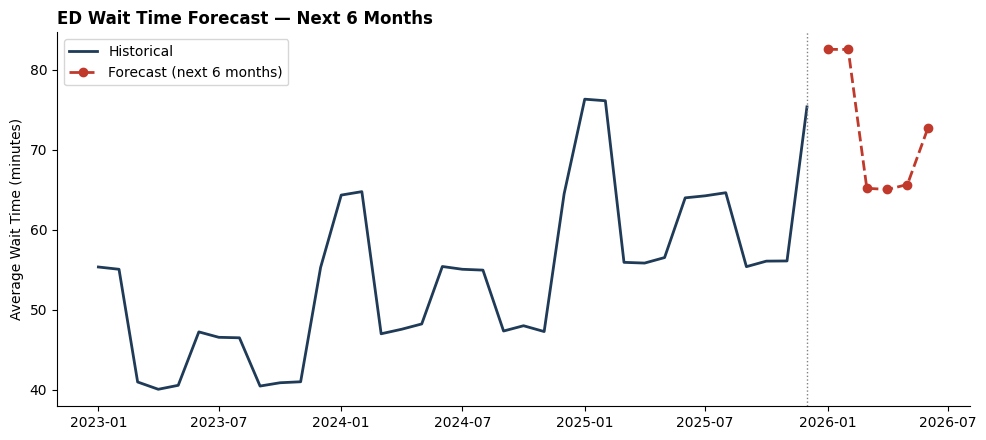

Forecasted average wait times (minutes):
2026-01-01    82.5
2026-02-01    82.5
2026-03-01    65.2
2026-04-01    65.0
2026-05-01    65.6
2026-06-01    72.7
Freq: MS, dtype: float64


In [6]:
ts = monthly.copy()
ts.index = pd.DatetimeIndex(ts.index)

model = ExponentialSmoothing(ts, trend="add", seasonal="add", seasonal_periods=12).fit()
forecast = model.forecast(6)

fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(ts.index, ts.values, color=NAVY, linewidth=2, label="Historical")
ax.plot(forecast.index, forecast.values, color=RED, linewidth=2, linestyle="--", marker="o", label="Forecast (next 6 months)")
ax.axvline(ts.index[-1], color="grey", linestyle=":", linewidth=1)
ax.set_title("ED Wait Time Forecast — Next 6 Months", fontweight="bold", loc="left")
ax.set_ylabel("Average Wait Time (minutes)")
ax.legend()
plt.tight_layout()
plt.show()

print("Forecasted average wait times (minutes):")
print(forecast.round(1))


## 6. Key findings

- ED wait times and Night-shift understaffing both worsen over the same
  3-year window, but a same-day correlation test does **not** confirm a
  statistically significant daily relationship (p = 0.38) — an honest null
  result. The data available is logged at daily granularity, not by hour or
  shift, which limits how precisely this specific hypothesis can be tested.
  This is flagged as a data-collection gap worth fixing before treating
  staffing as a confirmed root cause.
- Wait time increases meaningfully with less-urgent triage levels (ANOVA
  p < 0.001, F = 69,141) — as expected clinically, but the *magnitude* (triage
  5 patients waiting roughly 9x longer than triage 1) quantifies a concrete
  fast-track opportunity regardless of the staffing question.
- If current trends continue unaddressed, the 6-month forecast shows wait
  times staying elevated (65-82 minutes), giving leadership a concrete
  reference point rather than only a historical chart.

**Next:** the triage-level fast-track opportunity is the strongest,
best-supported lever from this notebook. The staffing/wait-time relationship
needs finer-grained data before being treated as confirmed — this distinction
matters for how confidently that recommendation gets stated in the final
report.
